# STEP 3 (Decision Tree) - Model Training
In this step, we're going to train Decision Tree for each personality trait and embedding.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns   
import numpy as np                                                                                                       
from sklearn.model_selection import train_test_split                                                                                                         
from sklearn.metrics import f1_score 
import joblib   
import os

from pipeline.smote_oversampling import SMOTEOversampler    
from pipeline.machine_learning_algorithms.decision_tree import DecisionTree


#### First, let's load the dataset and apply oversampling

In [2]:
df = pd.read_pickle('data/dataset_with_encodings/final_dataset_with_encodings.pkl')

In [3]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean,posts_tfidf_features,posts_w2v_features,augmented_posts_tfidf_features,augmented_posts_w2v_features,I_E,N_S,T_F,J_P
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.039469853, -0.3728942, -0.41033414, -0.1154...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19693445, -0.0025032638, 0.08193041, 0.1530...",I,N,F,J
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...,"[0.0, 0.06762042801527685, 0.0, 0.026240045055...","[0.078822784, -0.31084794, -0.40682986, -0.102...","[0.0, 0.0, 0.06401863001877148, 0.0, 0.0308183...","[0.22643407, 0.13486987, 0.13359053, 0.1418835...",E,N,T,P
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.07384879322521598, 0.031627841934...","[0.055956766, -0.31570536, -0.36344454, -0.075...","[0.0, 0.0, 0.0, 0.0, 0.0658605765698715, 0.032...","[0.19347186, 0.021339012, 0.09674486, 0.159254...",I,N,T,P
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,...","[-0.019194897, -0.37407914, -0.5568112, -0.182...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.05199321424315832,...","[0.21894899, 0.21582802, 0.18478529, 0.2388864...",I,N,T,J
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.057541147, -0.29415804, -0.45218706, -0.204...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19203198, 0.121340014, -0.008840058, 0.0499...",E,N,T,J


TFIDF oversampling

In [ ]:
X = np.stack(df["augmented_posts_tfidf_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                                                              
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

Original dataset shape: X=(6940, 10000), y=(6940,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [ ]:
def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df  

In [ ]:
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))                                                                

#### Now, We'll be training a model for TFIDF encodings

In [ ]:
mbti_clf_tfidf = MBTIDecisionTree(                                                                                              
    random_state=42,                                                                  
    max_depth=15,                                    
    min_samples_split=5                                                                                                      
) 

In [ ]:
mbti_clf_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [ ]:
mbti_clf_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.9055

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       401
           1       0.93      0.95      0.94      1334

    accuracy                           0.91      1735
   macro avg       0.88      0.85      0.86      1735
weighted avg       0.90      0.91      0.90      1735


Evaluation for dimension: N_S
Accuracy: 0.9014

              precision    recall  f1-score   support

           0       0.71      0.49      0.58       240
           1       0.92      0.97      0.94      1495

    accuracy                           0.90      1735
   macro avg       0.82      0.73      0.76      1735
weighted avg       0.89      0.90      0.89      1735


Evaluation for dimension: T_F
Accuracy: 0.7931

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       939
           1       0.78      0.76      0.77       796

    accuracy                       

In [ ]:
os.makedirs("models/decision_tree", exist_ok=True)
for key, value in mbti_clf_tfidf.models.items():                                                                               
    caminho = f"models/decision_tree/{key}_tfidf_dt.pkl"                                                                          
    joblib.dump(value, caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_tfidf_qwen.json
Salvo: models/xgboost/N_S_tfidf_qwen.json
Salvo: models/xgboost/T_F_tfidf_qwen.json
Salvo: models/xgboost/J_P_tfidf_qwen.json


#### Next, W2V encodings

In [ ]:
X = np.stack(df["augmented_posts_w2v_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                        
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)   

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [15]:
mbti_clf_w2v = XGBoostClassifier(                                                                                              
    n_estimators=400,                                                                  
    learning_rate=0.05,                                     
    max_depth=8,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [16]:
mbti_clf_w2v.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [17]:
mbti_clf_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.8524

              precision    recall  f1-score   support

           0       0.70      0.63      0.66       401
           1       0.89      0.92      0.91      1334

    accuracy                           0.85      1735
   macro avg       0.80      0.77      0.78      1735
weighted avg       0.85      0.85      0.85      1735


Evaluation for dimension: N_S
Accuracy: 0.8876

              precision    recall  f1-score   support

           0       0.60      0.57      0.58       240
           1       0.93      0.94      0.94      1495

    accuracy                           0.89      1735
   macro avg       0.76      0.75      0.76      1735
weighted avg       0.89      0.89      0.89      1735


Evaluation for dimension: T_F
Accuracy: 0.7741

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       939
           1       0.75      0.76      0.75       796

    accuracy                       

In [21]:
for key, value in mbti_clf_w2v.models.items():                                                                               
    caminho = f"models/xgboost/{key}_tfidf_qwen.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_tfidf_qwen.json
Salvo: models/xgboost/N_S_tfidf_qwen.json
Salvo: models/xgboost/T_F_tfidf_qwen.json
Salvo: models/xgboost/J_P_tfidf_qwen.json


#### Let's train a model for the posts before the augmentation, just as a matter of comparison

In [22]:
X = np.stack(df["posts_tfidf_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                        

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)  

def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    
                                                                 
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))    

Original dataset shape: X=(6940, 10000), y=(6940,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [23]:
mbti_clf_posts_tfidf = XGBoostClassifier(                                                                                              
    n_estimators=400,                                                                  
    learning_rate=0.05,                                     
    max_depth=8,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [24]:
mbti_clf_posts_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [25]:
mbti_clf_posts_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.8115

              precision    recall  f1-score   support

           0       0.71      0.31      0.43       401
           1       0.82      0.96      0.89      1334

    accuracy                           0.81      1735
   macro avg       0.77      0.64      0.66      1735
weighted avg       0.80      0.81      0.78      1735


Evaluation for dimension: N_S
Accuracy: 0.8772

              precision    recall  f1-score   support

           0       0.75      0.17      0.28       240
           1       0.88      0.99      0.93      1495

    accuracy                           0.88      1735
   macro avg       0.81      0.58      0.61      1735
weighted avg       0.86      0.88      0.84      1735


Evaluation for dimension: T_F
Accuracy: 0.7919

              precision    recall  f1-score   support

           0       0.80      0.81      0.81       939
           1       0.78      0.77      0.77       796

    accuracy                       

In [26]:
for key, value in mbti_clf_posts_tfidf.models.items():                                                                               
    caminho = f"models/xgboost/{key}_tfidf_qwen.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_tfidf_qwen.json
Salvo: models/xgboost/N_S_tfidf_qwen.json
Salvo: models/xgboost/T_F_tfidf_qwen.json
Salvo: models/xgboost/J_P_tfidf_qwen.json


In [27]:
X = np.stack(df["posts_w2v_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                        

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)  

def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    
                                                                 
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))    

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [28]:
mbti_clf_posts_w2v = XGBoostClassifier(                                                                                              
    n_estimators=400,                                                                  
    learning_rate=0.05,                                     
    max_depth=8,                                                      
    subsample=0.8,                                                                          
    colsample_bytree=0.8                                                                                                       
)    

In [29]:
mbti_clf_posts_w2v.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅


In [30]:
mbti_clf_posts_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7424

              precision    recall  f1-score   support

           0       0.40      0.24      0.30       401
           1       0.80      0.89      0.84      1334

    accuracy                           0.74      1735
   macro avg       0.60      0.57      0.57      1735
weighted avg       0.71      0.74      0.72      1735


Evaluation for dimension: N_S
Accuracy: 0.8501

              precision    recall  f1-score   support

           0       0.40      0.17      0.24       240
           1       0.88      0.96      0.92      1495

    accuracy                           0.85      1735
   macro avg       0.64      0.57      0.58      1735
weighted avg       0.81      0.85      0.82      1735


Evaluation for dimension: T_F
Accuracy: 0.7723

              precision    recall  f1-score   support

           0       0.80      0.77      0.78       939
           1       0.74      0.78      0.76       796

    accuracy                       

In [31]:
for key, value in mbti_clf_posts_w2v.models.items():                                                                               
    caminho = f"models/xgboost/{key}_tfidf_qwen.json"                                                                          
    value.save_model(caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/xgboost/I_E_tfidf_qwen.json
Salvo: models/xgboost/N_S_tfidf_qwen.json
Salvo: models/xgboost/T_F_tfidf_qwen.json
Salvo: models/xgboost/J_P_tfidf_qwen.json


#### Finally, the results of them 

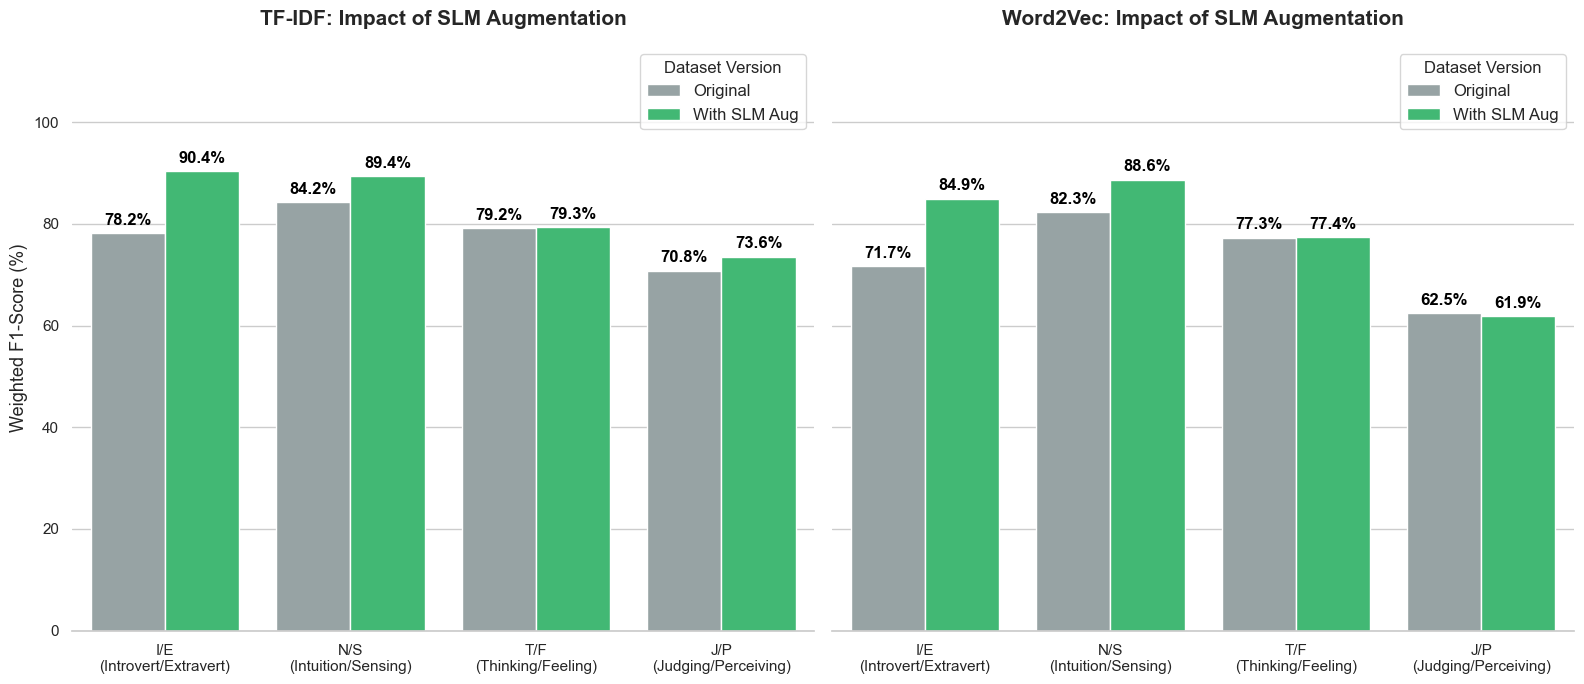

In [33]:
    # ==========================================                                                                                   
    # 1. Recreating the Original Test Data                                                                                         
    # ==========================================                                                                                   
    y = df["type"]                                                                                                                 
                                                                                                                                   
    # TF-IDF (Augmented and Original)                                                                                              
    X_tfidf_aug = np.stack(df["augmented_posts_tfidf_features"].values)                                                            
    _, X_test_tfidf_aug, _, y_test = train_test_split(X_tfidf_aug, y, test_size=0.2, random_state=42, stratify=y)                  
                                                                                                                                   
    X_tfidf_orig = np.stack(df["posts_tfidf_features"].values)                                                                     
    _, X_test_tfidf_orig, _, _ = train_test_split(X_tfidf_orig, y, test_size=0.2, random_state=42, stratify=y)                     
                                                                                                                                   
    # W2V (Augmented and Original)                                                                                                 
    X_w2v_aug = np.stack(df["augmented_posts_w2v_features"].values)                                                                
    _, X_test_w2v_aug, _, _ = train_test_split(X_w2v_aug, y, test_size=0.2, random_state=42, stratify=y)                           
                                                                                                                                   
    X_w2v_orig = np.stack(df["posts_w2v_features"].values)                                                                         
    _, X_test_w2v_orig, _, _ = train_test_split(X_w2v_orig, y, test_size=0.2, random_state=42, stratify=y)                         
                                                                                                                                   
    y_test_4cols = divide_mbti(y_test.reset_index(drop=True))                                                                      
                                                                                                                                   
    # ==========================================                                                                                   
    # 2. Generating Predictions                                                                                                    
    # ==========================================                                                                                   
    pred_tfidf_aug = mbti_clf_tfidf.predict(X_test_tfidf_aug)                                                                      
    pred_tfidf_orig = mbti_clf_posts_tfidf.predict(X_test_tfidf_orig)                                                              
                                                                                                                                   
    pred_w2v_aug = mbti_clf_w2v.predict(X_test_w2v_aug)                                                                            
    pred_w2v_orig = mbti_clf_posts_w2v.predict(X_test_w2v_orig)                                                                    
                                                                                                                                   
    # ==========================================                                                                                   
    # 3. Calculating Metrics                                                                                                       
    # ==========================================                                                                                   
    colunas = ['I_E', 'N_S', 'T_F', 'J_P']                                                                                         
    nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)',                            
  'J/P\n(Judging/Perceiving)']                                                                                                     
                                                                                                                                   
    dados = []                                                                                                                     
    for i, col in enumerate(colunas):                                                                                              
        # TF-IDF                                                                                                                   
        f1_t_aug = f1_score(y_test_4cols[col], pred_tfidf_aug[col], average='weighted') * 100                                      
        f1_t_orig = f1_score(y_test_4cols[col], pred_tfidf_orig[col], average='weighted') * 100                                    
        dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_orig, 'Augmentation': 'Original', 'Embedding': 'TF-IDF'})             
        dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_aug, 'Augmentation': 'With SLM Aug', 'Embedding': 'TF-IDF'})          
                                                                                                                                   
        # Word2Vec                                                                                                                 
        f1_w_aug = f1_score(y_test_4cols[col], pred_w2v_aug[col], average='weighted') * 100                                        
        f1_w_orig = f1_score(y_test_4cols[col], pred_w2v_orig[col], average='weighted') * 100                                      
        dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_orig, 'Augmentation': 'Original', 'Embedding': 'Word2Vec'})           
        dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_aug, 'Augmentation': 'With SLM Aug', 'Embedding': 'Word2Vec'})        
                                                                                                                                   
    df_plot = pd.DataFrame(dados)                                                                                                  
                                                                                                                                   
    # ==========================================                                                                                   
    # 4. Building the Plots                                                                                                        
    # ==========================================                                                                                   
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)                                                                   
    sns.set_theme(style="whitegrid")                                                                                               
    paleta = ['#95a5a6', '#2ecc71']                                                                                                
                                                                                                                                   
    # Panel 1: TF-IDF
    sns.barplot(data=df_plot[df_plot['Embedding'] == 'TF-IDF'], x='Axis', y='F1 (%)', hue='Augmentation', palette=paleta,          
  ax=axes[0])
    axes[0].set_title("TF-IDF: Impact of SLM Augmentation", fontsize=15, fontweight='bold', pad=15)                                
    axes[0].set_ylim(0, 115)
    axes[0].set_ylabel("Weighted F1-Score (%)", fontsize=13)
    axes[0].set_xlabel("")
  
    # Panel 2: Word2Vec
    sns.barplot(data=df_plot[df_plot['Embedding'] == 'Word2Vec'], x='Axis', y='F1 (%)', hue='Augmentation', palette=paleta,        
  ax=axes[1])
    axes[1].set_title("Word2Vec: Impact of SLM Augmentation", fontsize=15, fontweight='bold', pad=15)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")
  
    # Formatting Data Labels and Legends
    for ax in axes:
        for p in ax.patches:
            altura = p.get_height()
            if altura > 0:
                ax.annotate(f"{altura:.1f}%", (p.get_x() + p.get_width() / 2., altura), 
                            ha='center', va='baseline', fontsize=12, fontweight='bold', color='black', 
                            xytext=(0, 6), textcoords='offset points')
        ax.legend(title='Dataset Version', fontsize='12', loc='upper right')
  
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()